# UAH Feature Engineering

## Objective

This notebook transforms synchronized sensor measurements into meaningful features that describe driving behaviour.

The generated features will later be used to train machine learning models.

This notebook focuses on:

- Signal magnitude features
- Statistical features
- Motion features
- GPS-derived features
- Rolling window features

No machine learning model is trained in this notebook.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
master_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/master_dataset_D1_NORMAL1.csv"

master_df = pd.read_csv(master_path)

master_df.head()

,timestamp,active,acc_x,acc_y,acc_z,acc_x_kf,acc_y_kf,acc_z_kf,roll,pitch,...,latitude,longitude,altitude,gps_quality,satellites,heading,extra_1,extra_2,extra_3,extra_4
0,6.94,1,0.017,-0.011,0.018,-0.005,0.008,0.018,-1.523,0.015,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
1,7.03,1,0.046,0.007,0.019,0.016,-0.002,0.018,-1.522,0.012,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
2,7.14,1,0.052,-0.016,0.027,0.037,-0.005,0.018,-1.520,0.014,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
3,7.24,1,0.015,-0.016,0.026,0.038,-0.009,0.024,-1.523,0.014,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0
4,7.34,1,-0.014,-0.017,0.040,0.012,-0.016,0.032,-1.525,0.012,...,40.512787,-3.404477,612.7,4,5,331.9,0.0,0,0,0


In [5]:
master_df["acc_resultant"] = np.sqrt(
    master_df["acc_x"]**2 +
    master_df["acc_y"]**2 +
    master_df["acc_z"]**2
)

In [6]:
master_df["acc_horizontal"] = np.sqrt(
    master_df["acc_x"]**2 +
    master_df["acc_y"]**2
)

In [7]:
master_df["acc_vertical"] = master_df["acc_z"]

In [8]:
master_df[
    [
        "acc_resultant",
        "acc_horizontal",
        "acc_vertical"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
acc_resultant,6170.0,0.047316,0.028211,0.002449,0.028618,0.041719,0.058756,0.252256
acc_horizontal,6170.0,0.041927,0.028346,0.000000,0.022847,0.036056,0.053254,0.251205
acc_vertical,6170.0,-0.001793,0.021682,-0.125000,-0.013000,-0.001000,0.011000,0.090000


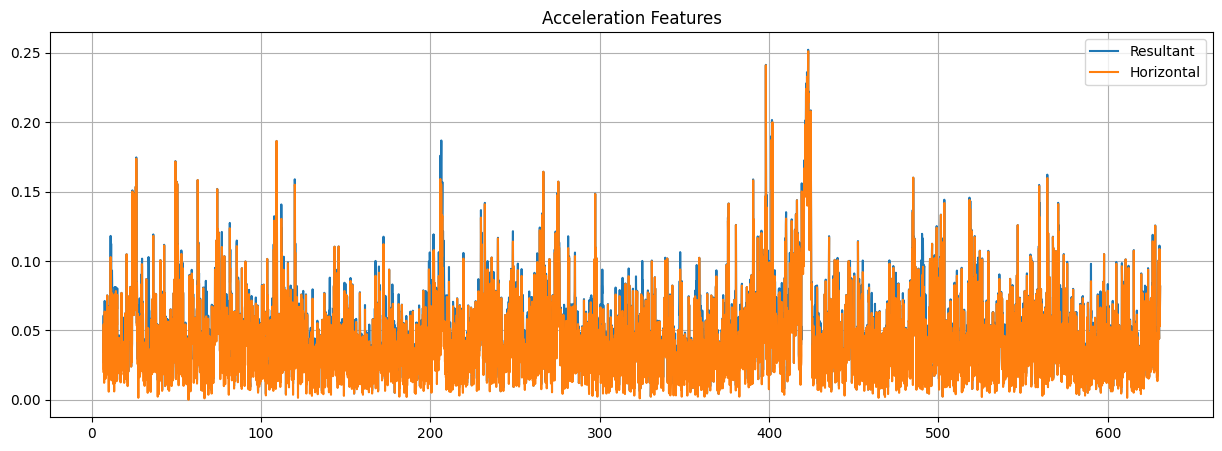

In [9]:
plt.figure(figsize=(15,5))

plt.plot(master_df["timestamp"],
         master_df["acc_resultant"],
         label="Resultant")

plt.plot(master_df["timestamp"],
         master_df["acc_horizontal"],
         label="Horizontal")

plt.legend()

plt.grid(True)

plt.title("Acceleration Features")

plt.show()

In [12]:
master_df["roll_delta"] = master_df["roll"].diff().fillna(0)

master_df["pitch_delta"] = master_df["pitch"].diff().fillna(0)

master_df["yaw_delta"] = master_df["yaw"].diff().fillna(0)

In [13]:
new_features = [
    "speed_delta",
    "heading_delta",
    "roll_delta",
    "pitch_delta",
    "yaw_delta"
]

master_df[new_features].describe().T

,count,mean,std,min,25%,50%,75%,max
speed_delta,6170.0,0.003663,0.413470,-6.000,0.000,0.0,0.000,9.700
heading_delta,6170.0,-0.008720,0.526080,-6.400,0.000,0.0,0.000,6.300
roll_delta,6170.0,-0.000001,0.001968,-0.011,-0.001,0.0,0.001,0.018
pitch_delta,6170.0,-0.000004,0.003188,-0.025,-0.002,0.0,0.001,0.039
yaw_delta,6170.0,-0.000209,0.002354,-0.018,-0.001,0.0,0.001,0.009


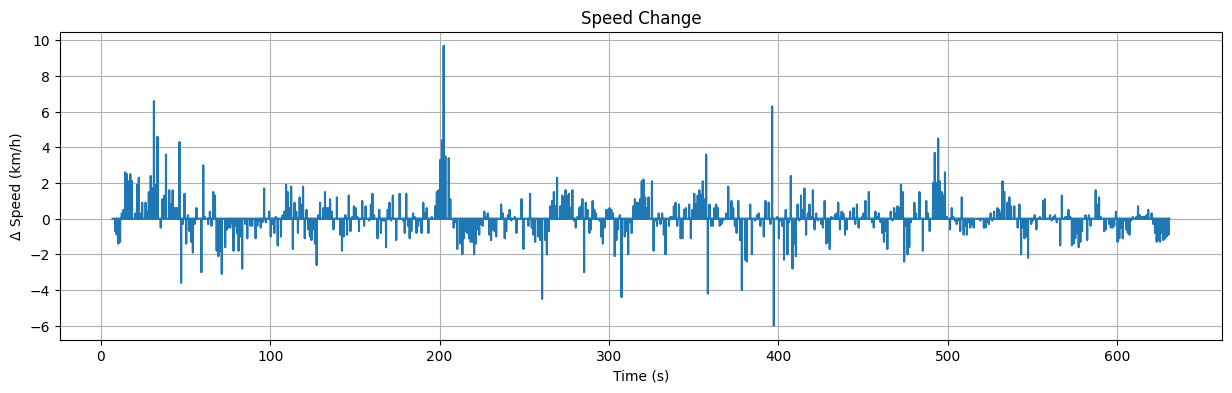

In [14]:
plt.figure(figsize=(15,4))

plt.plot(
    master_df["timestamp"],
    master_df["speed_delta"]
)

plt.title("Speed Change")

plt.xlabel("Time (s)")
plt.ylabel("Δ Speed (km/h)")

plt.grid(True)

plt.show()

In [16]:
output_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed"

os.makedirs(output_path, exist_ok=True)

master_df.to_csv(
    os.path.join(output_path, "master_dataset_features.csv"),
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


# Conclusion

In this notebook, eight basic motion-related features were engineered from the synchronized accelerometer, GPS and orientation signals.

These features provide a more meaningful representation of vehicle dynamics than the raw sensor values alone.

The generated features will be used in the next notebook to create rolling-window statistical features for machine learning.